In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CRight']]
config.session_type = 'S2'


config.test_session = 1


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0
config.stride = 0.5



config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']


model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 750, 1))
model.summary()

model = NetCNN1D(len(config.used_classes))
model.build((32, 750, 3))
model.summary()





Model: "net_cnn2d_csp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 3, 108, 16)          608       
                                                                 
 sequential_1 (Sequential)   (32, 3, 22, 32)           10912     
                                                                 
 sequential_2 (Sequential)   (32, 32)                  0         
                                                                 
 fc (Sequential)             (32, 2)                   4482      
                                                                 
Total params: 16002 (62.51 KB)
Trainable params: 15906 (62.13 KB)
Non-trainable params: 96 (384.00 Byte)
_________________________________________________________________
Model: "net_cnn1d"
_________________________________________________________________
 Layer (type)                Output Shape              Pa

In [2]:
config.used_classes = [['CLeft'], ['CRight']]#, ['CUp'], ['CDown']]
config.session_type = 'S2'

X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

(316, 13, 750)
(316,)


Training indices:  [  0   1   2   3   4   5   6   8   9  10  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  29  30  31  32  34  35  36  37  38  40
  41  42  43  44  46  47  48  50  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  69  70  72  73  74  77  79  80  82  83  85  86
  87  88  90  92  93  94  95  96  97  99 100 101 102 103 104 105 107 108
 109 111 112 114 115 116 118 119 120 122 123 124 125 128 129 130 131 132
 133 134 136 137 139 140 141 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 159 160 162 163 164 165 167 169 170 171 172 174 176 177
 178 179 180 181 182 184 185 186 187 189 190 191 192 193 194 195 196 197
 198 199 200 201 204 205 206 207 210 211 213 214 215 216 217 218 220 222
 223 224 225 227 228 229 232 233 234 235 237 238 239 240 242 243 246 247
 248 249 250 252 253 254 255 256 257 259 260 262 265 266 267 268 269 271
 272 274 275 276 277 278 279 280 281 282 284 285 286 287 288 289 290 292
 293 294 296 297 298 299 300 301

INFO:tensorflow:Assets written to: best_model_fold_0.tf\assets


24/24 [==============================] - 7s 170ms/step - loss: 0.7006 - acc: 0.4630 - val_loss: 0.6928 - val_acc: 0.5208
Epoch 2/100
24/24 [==============================] - 1s 35ms/step - loss: 0.6851 - acc: 0.5225 - val_loss: 0.6923 - val_acc: 0.5521
Epoch 3/100
24/24 [==============================] - 1s 32ms/step - loss: 0.6811 - acc: 0.5569 - val_loss: 0.6919 - val_acc: 0.5469
Epoch 4/100
24/24 [==============================] - 1s 30ms/step - loss: 0.6776 - acc: 0.5714 - val_loss: 0.6917 - val_acc: 0.5573
Epoch 5/100
24/24 [==============================] - 1s 29ms/step - loss: 0.6721 - acc: 0.5648 - val_loss: 0.6918 - val_acc: 0.5469
Epoch 6/100
24/24 [==============================] - 1s 34ms/step - loss: 0.6732 - acc: 0.5913 - val_loss: 0.6924 - val_acc: 0.5469
Epoch 7/100
24/24 [==============================] - 1s 30ms/step - loss: 0.6711 - acc: 0.5608 - val_loss: 0.6928 - val_acc: 0.5469
Epoch 8/100
23/24 [===========================>..] - ETA: 0s - loss: 0.6741 - acc: 0.57

INFO:tensorflow:Assets written to: best_model_fold_0.tf\assets


24/24 [==============================] - 5s 200ms/step - loss: 0.6723 - acc: 0.5820 - val_loss: 0.6942 - val_acc: 0.5365
Epoch 9/100
23/24 [===========================>..] - ETA: 0s - loss: 0.6716 - acc: 0.5842INFO:tensorflow:Assets written to: best_model_fold_0.tf\assets


...

24/24 [==============================] - 4s 166ms/step - loss: 0.5415 - acc: 0.7549 - val_loss: 0.7166 - val_acc: 0.5397
Epoch 98/100
23/24 [===========================>..] - ETA: 0s - loss: 0.5457 - acc: 0.7582INFO:tensorflow:Assets written to: best_model_fold_4.tf\assets


INFO:tensorflow:Assets written to: best_model_fold_4.tf\assets


24/24 [==============================] - 5s 206ms/step - loss: 0.5447 - acc: 0.7602 - val_loss: 0.7222 - val_acc: 0.5238
Epoch 99/100
24/24 [==============================] - 1s 38ms/step - loss: 0.5355 - acc: 0.7668 - val_loss: 0.7167 - val_acc: 0.5344
Epoch 100/100
24/24 [==============================] - 1s 38ms/step - loss: 0.5378 - acc: 0.7470 - val_loss: 0.7192 - val_acc: 0.5344
INFO:tensorflow:Assets written to: best_model.tf\assets


INFO:tensorflow:Assets written to: best_model.tf\assets


Best model saved (Fold 1) with validation accuracy: 0.5979



58.13% +- 1.8


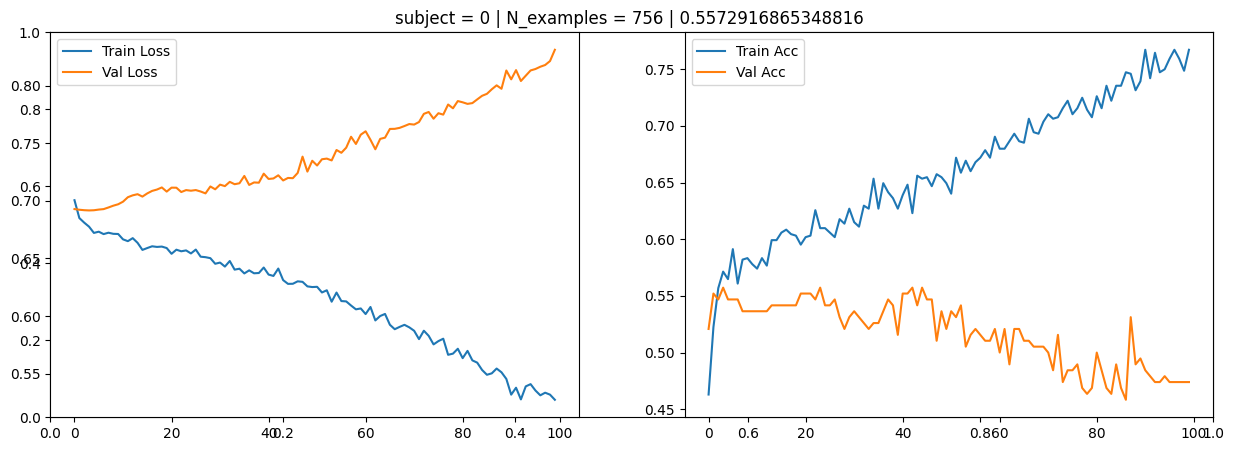

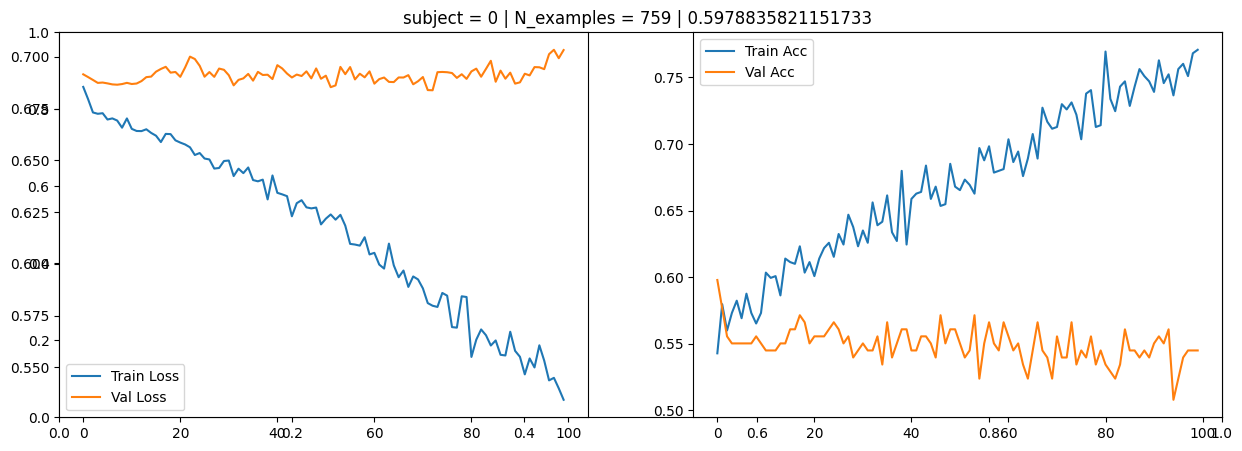

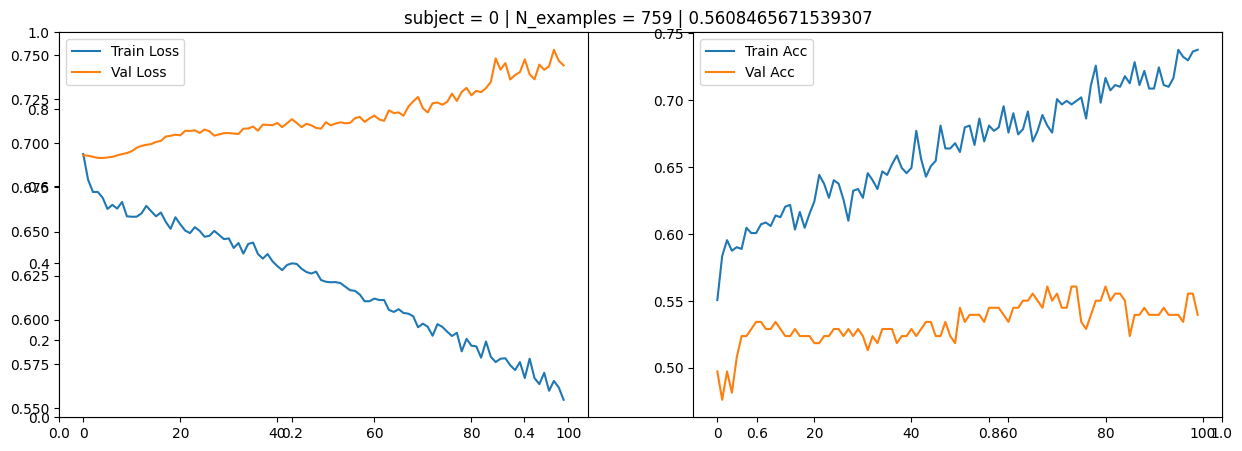

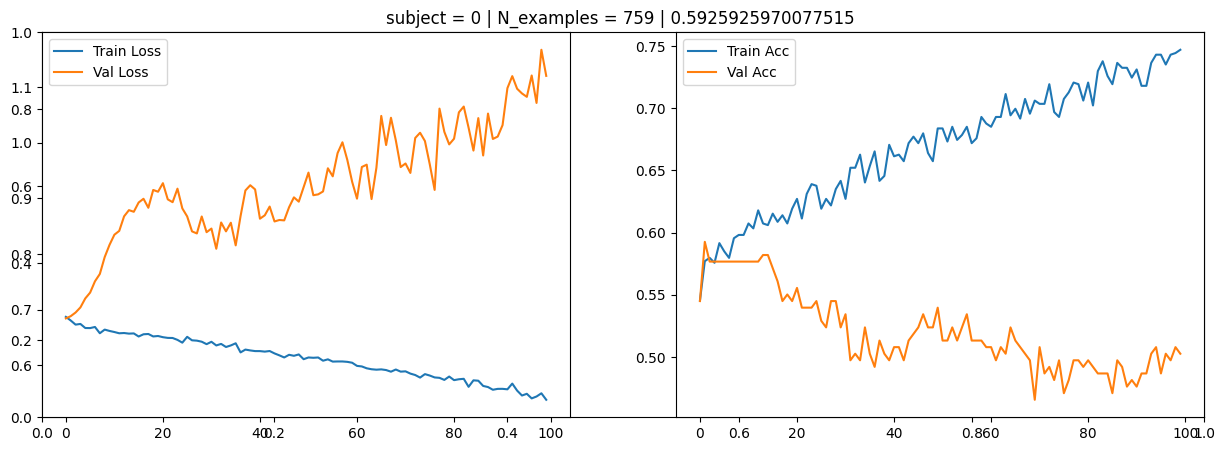

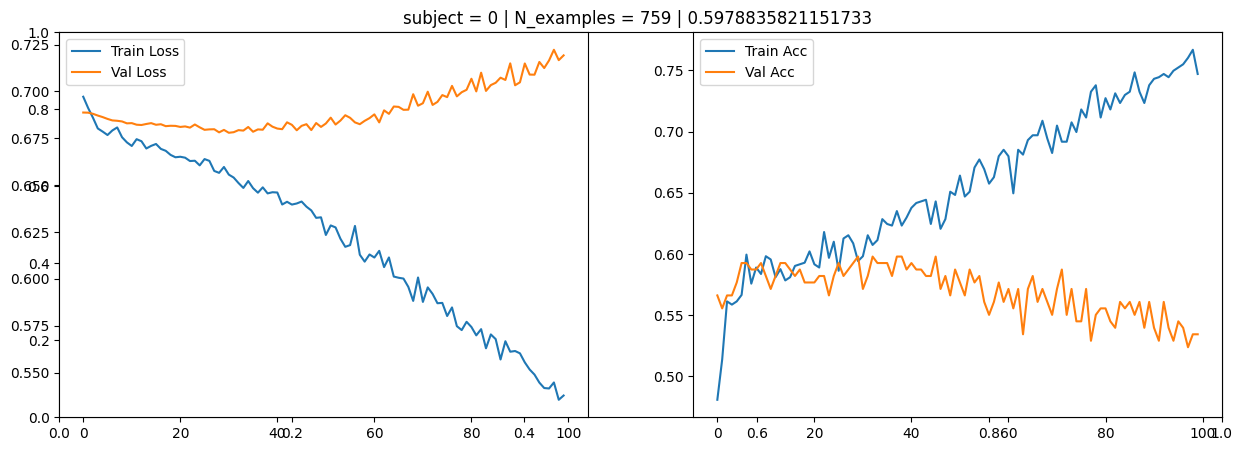

In [4]:
crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]


best_model = None
best_acc = 0
best_fold_idx = 0
best_csp = None


for fold_idx, (train_index, valid_index) in enumerate(crossValidation_KF.split(X,y)):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print("Training indices: ", train_index)
    print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    model = NetCNN1D(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=2e-4, weight_decay = 1e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    checkpoint_cb = ModelCheckpoint(f'best_model_fold_{fold_idx}.tf', save_best_only=True, monitor='val_loss', mode='max', verbose=0, save_format='tf')

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=100, batch_size=32, verbose=1, callbacks=[checkpoint_cb])

    
    val_acc = max(history.history['val_acc'])
    acc.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        best_fold_idx = fold_idx
        best_csp = csp 



    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    

if best_model is not None:
    best_model.save('best_model.tf', save_format='tf')
    print(f"Best model saved (Fold {best_fold_idx}) with validation accuracy: {best_acc:.4f}")

    with open('csp.pkl', 'wb') as f:
        pickle.dump(best_csp, f)


print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")




In [37]:
model = tf.keras.models.load_model('best_model.tf')
#model.trainable = False 

with open('csp.pkl', 'rb') as f:
    csp = pickle.load(f)

for layer in model.layers:
    layer.trainable = False

    if layer.name == 'fc':
        layer.trainable = True

config.stride = 0.1

X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')

In [38]:
X = csp.transform(X)

X = X.transpose(0, 2, 1)
#X = np.expand_dims(X, 3)


y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))

print(X.shape)

model.evaluate(X, y)

(31, 750, 3)


ValueError: in user code:

    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\keras\src\engine\training.py", line 2066, in test_function  *
        return step_function(self, iterator)
    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\keras\src\engine\training.py", line 2049, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\keras\src\engine\training.py", line 2037, in run_step  **
        outputs = model.test_step(data)
    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\keras\src\engine\training.py", line 1917, in test_step
        y_pred = self(x, training=False)
    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None

    ValueError: Could not find mat

Training indices:  [ 1  3  4  5  6  7  8 10 11 12 13 15 16 17 18 19 20 21 22 23 24 26 28 29]
Validation indices:  [ 0  2  9 14 25 27 30]
Epoch 1/100
17/17 [==============================] - 3s 45ms/step - loss: 0.7736 - acc: 0.5114 - val_loss: 0.8402 - val_acc: 0.5325
Epoch 2/100
17/17 [==============================] - 0s 9ms/step - loss: 0.7366 - acc: 0.5455 - val_loss: 0.7843 - val_acc: 0.5195
Epoch 3/100
17/17 [==============================] - 0s 10ms/step - loss: 0.7241 - acc: 0.5417 - val_loss: 0.7605 - val_acc: 0.5325
Epoch 4/100
17/17 [==============================] - 0s 9ms/step - loss: 0.6985 - acc: 0.5871 - val_loss: 0.7530 - val_acc: 0.5195
Epoch 5/100
17/17 [==============================] - 0s 8ms/step - loss: 0.6832 - acc: 0.5606 - val_loss: 0.7378 - val_acc: 0.5195
Epoch 6/100
17/17 [==============================] - 0s 8ms/step - loss: 0.6619 - acc: 0.6364 - val_loss: 0.7206 - val_acc: 0.5065
Epoch 7/100
17/17 [==============================] - 0s 8ms/step - loss: 0.

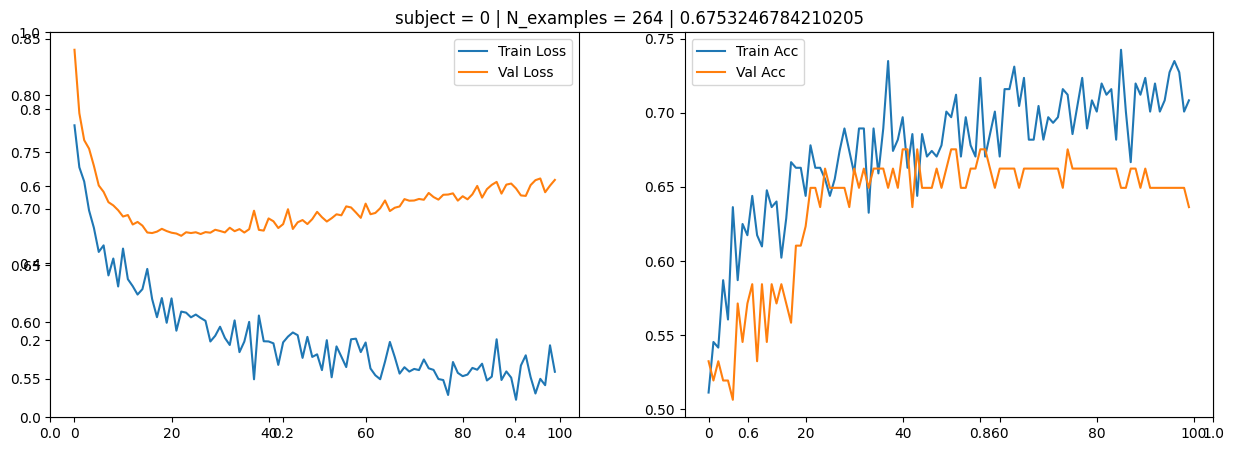

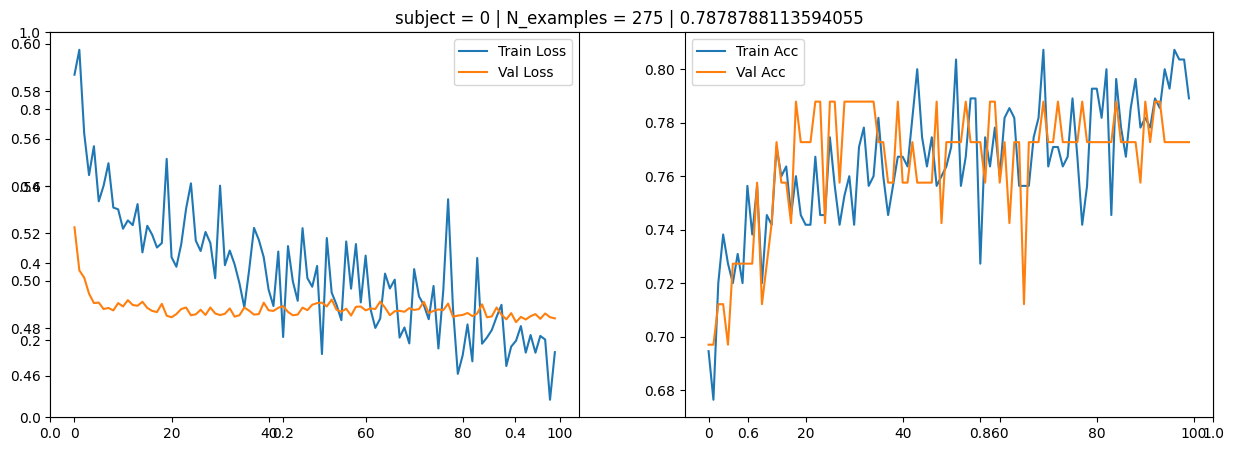

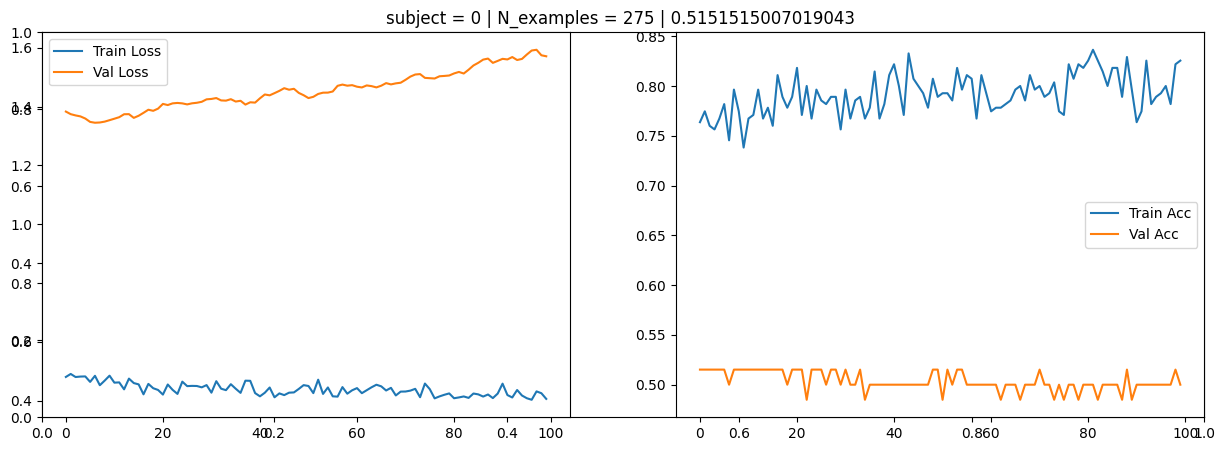

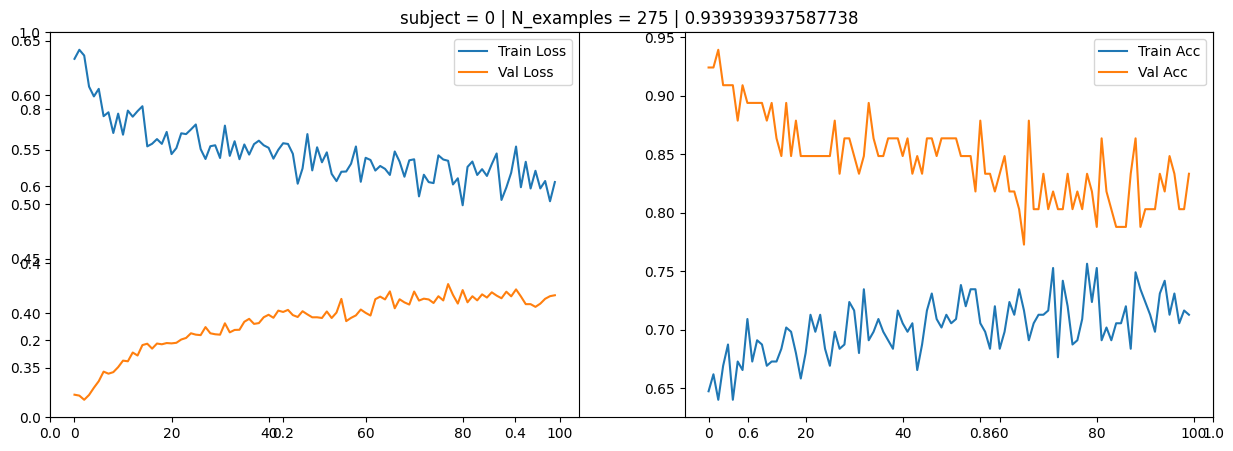

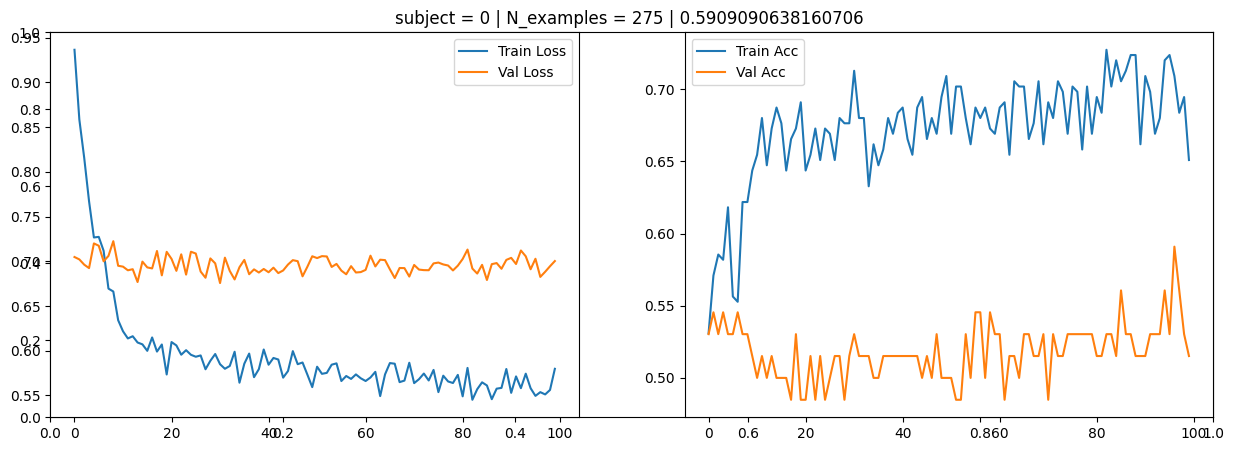

In [9]:
crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y))



X = X[shuffle_indices]
y = y[shuffle_indices]

for train_index, valid_index in crossValidation_KF.split(X,y):


    X_train = X[train_index]
    Y_train = y[train_index]
    X_valid = X[valid_index]
    Y_valid = y[valid_index]
    print("Training indices: ", train_index)
    print("Validation indices: ", valid_index)


    # A better alternative is to slice the dataset before for preocessing time efficiency, however since our dataset is extremely small it doesn't matter in this case.
    X_train, Y_train = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)


    #mu = X_train.mean()
    #sig = X_train.std()

    #X_train = (X_train - mu)/sig
    #X_valid = (X_valid - mu)/sig



    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')



    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    #X_train = csp.transform(X_train)
    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)

    sys.stdout.close()
    sys.stdout = old_stdout

    #print(X_train.shape)
    #X_train = np.expand_dims(X_train, 3)
    #X_valid = np.expand_dims(X_valid, 3)

    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = len(config.used_classes))
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))



    #model = NetCNN2D_CSP(len(config.used_classes)) #NetCNN2D_CSP(len(config.used_classes)) 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.01),
            optimizer=keras.optimizers.Adam(learning_rate=5e-4, weight_decay = 5e-7), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=100, batch_size=16, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))
    

print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")


